In [11]:
import torch
import pandas as pd
from matplotlib import pyplot as plt
import joblib
import numpy as np

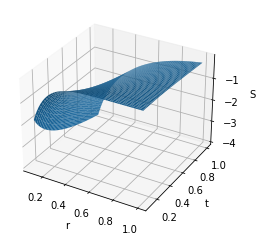

In [8]:
list_of_paths = ["training_results\ems\DQN_20240506_051439",
                 "training_results\ems\DQN_20240506_050557",
                 "training_results\ems\DQN_20240506_045750",
                 "training_results\ems\DQN_20240506_044943",
                 ]

In [6]:
import os

folder_path = ".\\training_results\\ems"
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]

models = []
scalers = []

for path in subfolders:
    models.append(torch.load(path + "\\policy.pt"))

    scalers.append(joblib.load(path + "\\scaler.pkl"))



In [9]:
from environments.EMS_env import EMS_env

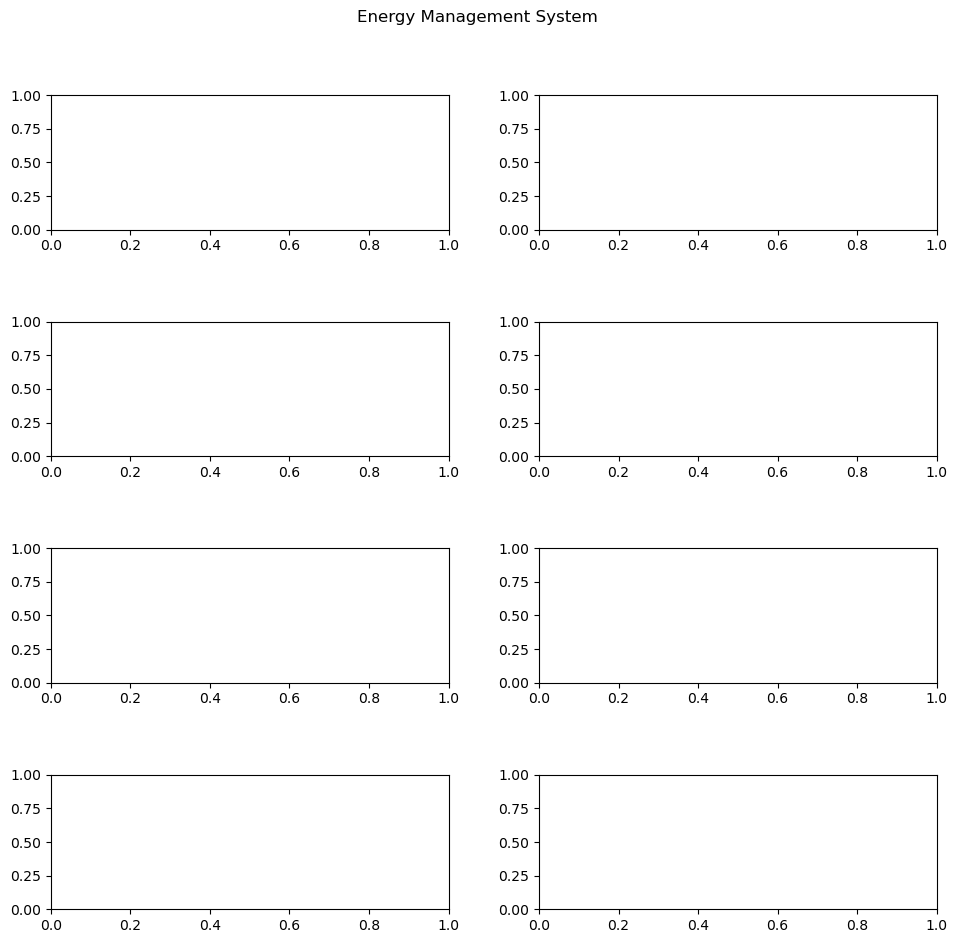

In [10]:
env = EMS_env()

In [19]:
stat_def = []
stat_pen = []
for i in range(len(models)):
    total_steps = 0
    num_deficit = 0
    num_pen = 0
    for i in range(20):
        total_steps += 288
        states, actions, rews = env.sample_trajectory(models[0], scalers[0], max_steps=288)
        num_deficit += np.sum(states[1:,-1]<0)
        num_pen += np.sum(np.logical_and(actions[:,0]>0, states[:-1,4]>=5))
   
    print(num_deficit/total_steps)
    print(num_pen/total_steps)
    stat_def.append(num_deficit/total_steps)
    stat_pen.append(num_pen/total_steps)
    




Accumulated power consumed: 0.32028837778299196
Accumulated power consumed: 0.21241438436889726
Accumulated power consumed: 0.3496483655723771
Accumulated power consumed: 0.24158735150094907
Accumulated power consumed: 0.2372404346601595
Accumulated power consumed: 0.33952337022080015
Accumulated power consumed: 0.42930003791071153
Accumulated power consumed: 0.18937745120650593
Accumulated power consumed: 0.3515701815879759
Accumulated power consumed: 0.359272569429768
Accumulated power consumed: 0.18940747636544436
Accumulated power consumed: 0.32030306656315405
Accumulated power consumed: 0.42861285345833094
Accumulated power consumed: 0.33608003379372553
Accumulated power consumed: 0.33279037584025456
Accumulated power consumed: 0.313106280032077
Accumulated power consumed: 0.2197754023400774
Accumulated power consumed: 0.45499142510623675
Accumulated power consumed: 0.31846066749368906
Accumulated power consumed: 0.23709439537786625
0.11631944444444445
0.0
Accumulated power consum

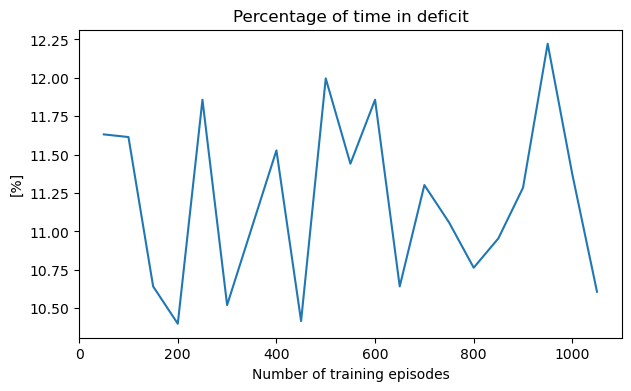

In [36]:
a = np.linspace(50, 50*21 , len(stat_def))
plt.plot(a, np.array(stat_def)*100)
plt.title("Percentage of time in deficit")
plt.ylabel("[%]")
plt.xlabel("Number of training episodes")

fig = plt.gcf()
fig.set_size_inches(7, 4)
fig.savefig("deficit.png", dpi=300) 


In [16]:
import numpy as np

a = np.array([True, False, True, False])
b = np.array([True, True, False, False])

result = np.logical_and(a, b)
print(result)


[ True False False False]


In [38]:
env.show_sample(models[-1], scalers[-1])

Accumulated power consumed: 0.5180918000313575


In [40]:
env.fig.savefig("sample.png", dpi=300)

: 